# SATAY-ViT GPU Training Pipeline
This notebook trains the ME-ViT Reasoner on your local NVIDIA GPU using the **offline-preprocessed** COCO-Tasks dataset.

In [1]:
import os, sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# --- Configuration ---
PIPELINE_DIR = "e:/DVcon/DVcon/Pipelines/satay_vit"
DATA_ROOT    = "e:/DVcon/DVcon/Data_Preprocessed"
WEIGHTS_DIR  = os.path.join(PIPELINE_DIR, "weights")
BATCH_SIZE   = 16
EPOCHS       = 10
LR           = 1e-4

# Add pipeline directory to path so local modules resolve correctly
if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)

os.makedirs(WEIGHTS_DIR, exist_ok=True)

# CUDA check
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

CUDA Available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
Using device: cuda


## 0. Verify Preprocessed Data Exists

In [2]:
train_manifest = os.path.join(DATA_ROOT, 'train', 'samples.json')
test_manifest  = os.path.join(DATA_ROOT, 'test',  'samples.json')

if not os.path.exists(train_manifest) or not os.path.exists(test_manifest):
    print("Preprocessed data not found! Running preprocess_dataset.py now...")
    import subprocess
    result = subprocess.run(
        [sys.executable, os.path.join(PIPELINE_DIR, 'preprocess_dataset.py')],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print("ERROR:", result.stderr)
        raise RuntimeError("Preprocessing failed. Check the error above.")
else:
    import json
    with open(train_manifest) as f: tr = json.load(f)
    with open(test_manifest)  as f: te = json.load(f)
    print(f"Preprocessed data ready!")
    print(f"  Train samples : {len(tr):,}")
    print(f"  Test  samples : {len(te):,}")

Preprocessed data ready!
  Train samples : 100,800
  Test  samples : 12,600


## 1. Load Dataset & Build DataLoaders

In [3]:
from data_loader import COCOTasksDataset, custom_collate

train_dataset = COCOTasksDataset(DATA_ROOT, split='train')
val_dataset   = COCOTasksDataset(DATA_ROOT, split='test')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, collate_fn=custom_collate)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Loaded 100800 PREPROCESSED samples for train split.
Loaded 12600 PREPROCESSED samples for test split.
Train batches: 6300 | Val batches: 788


## 2. Initialize Model, Optimizer & Loss

In [4]:
from model import MEViTReasoner

model     = MEViTReasoner().to(device)
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"ME-ViT Reasoner | Trainable parameters: {total_params:,}")

ME-ViT Reasoner | Trainable parameters: 7,327,744


## 3. Training Loop (CUDA Accelerated)

In [5]:
best_val_loss = float('inf')
train_history = []
val_history   = []

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for batch in pbar:
        imgs       = batch['image'].to(device)
        tasks      = batch['task_id'].to(device)
        gt_hmaps   = batch['heatmap'].to(device)

        optimizer.zero_grad()
        pred_hmaps = model(imgs, tasks)
        loss       = criterion(pred_hmaps, gt_hmaps)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train = train_loss / len(train_loader)

    # --- Validate ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]"):
            imgs     = batch['image'].to(device)
            tasks    = batch['task_id'].to(device)
            gt_hmaps = batch['heatmap'].to(device)
            pred_hmaps = model(imgs, tasks)
            val_loss  += criterion(pred_hmaps, gt_hmaps).item()

    avg_val = val_loss / len(val_loader)
    train_history.append(avg_train)
    val_history.append(avg_val)
    print(f"Epoch {epoch+1:>2} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        ckpt_path = os.path.join(WEIGHTS_DIR, 'mevit_best.pt')
        torch.save(model.state_dict(), ckpt_path)
        print(f"  ==> Saved best model -> {ckpt_path}")

Epoch 1/10 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/788 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 0.1722 | Val Loss: 0.1610
  ==> Saved best model -> e:/DVcon/DVcon/Pipelines/satay_vit\weights\mevit_best.pt


Epoch 2/10 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

Epoch 2/10 [Valid]:   0%|          | 0/788 [00:00<?, ?it/s]

...

Epoch 9/10 [Valid]:   0%|          | 0/788 [00:00<?, ?it/s]

Epoch  9 | Train Loss: 0.1613 | Val Loss: 0.1557


Epoch 10/10 [Train]:   0%|          | 0/6300 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/788 [00:00<?, ?it/s]

Epoch 10 | Train Loss: 0.1613 | Val Loss: 0.1546


## 4. Training Curve (Overfit/Underfit Analysis)

Loss curve saved to: e:/DVcon/DVcon/Pipelines/satay_vit\weights\loss_curve.png


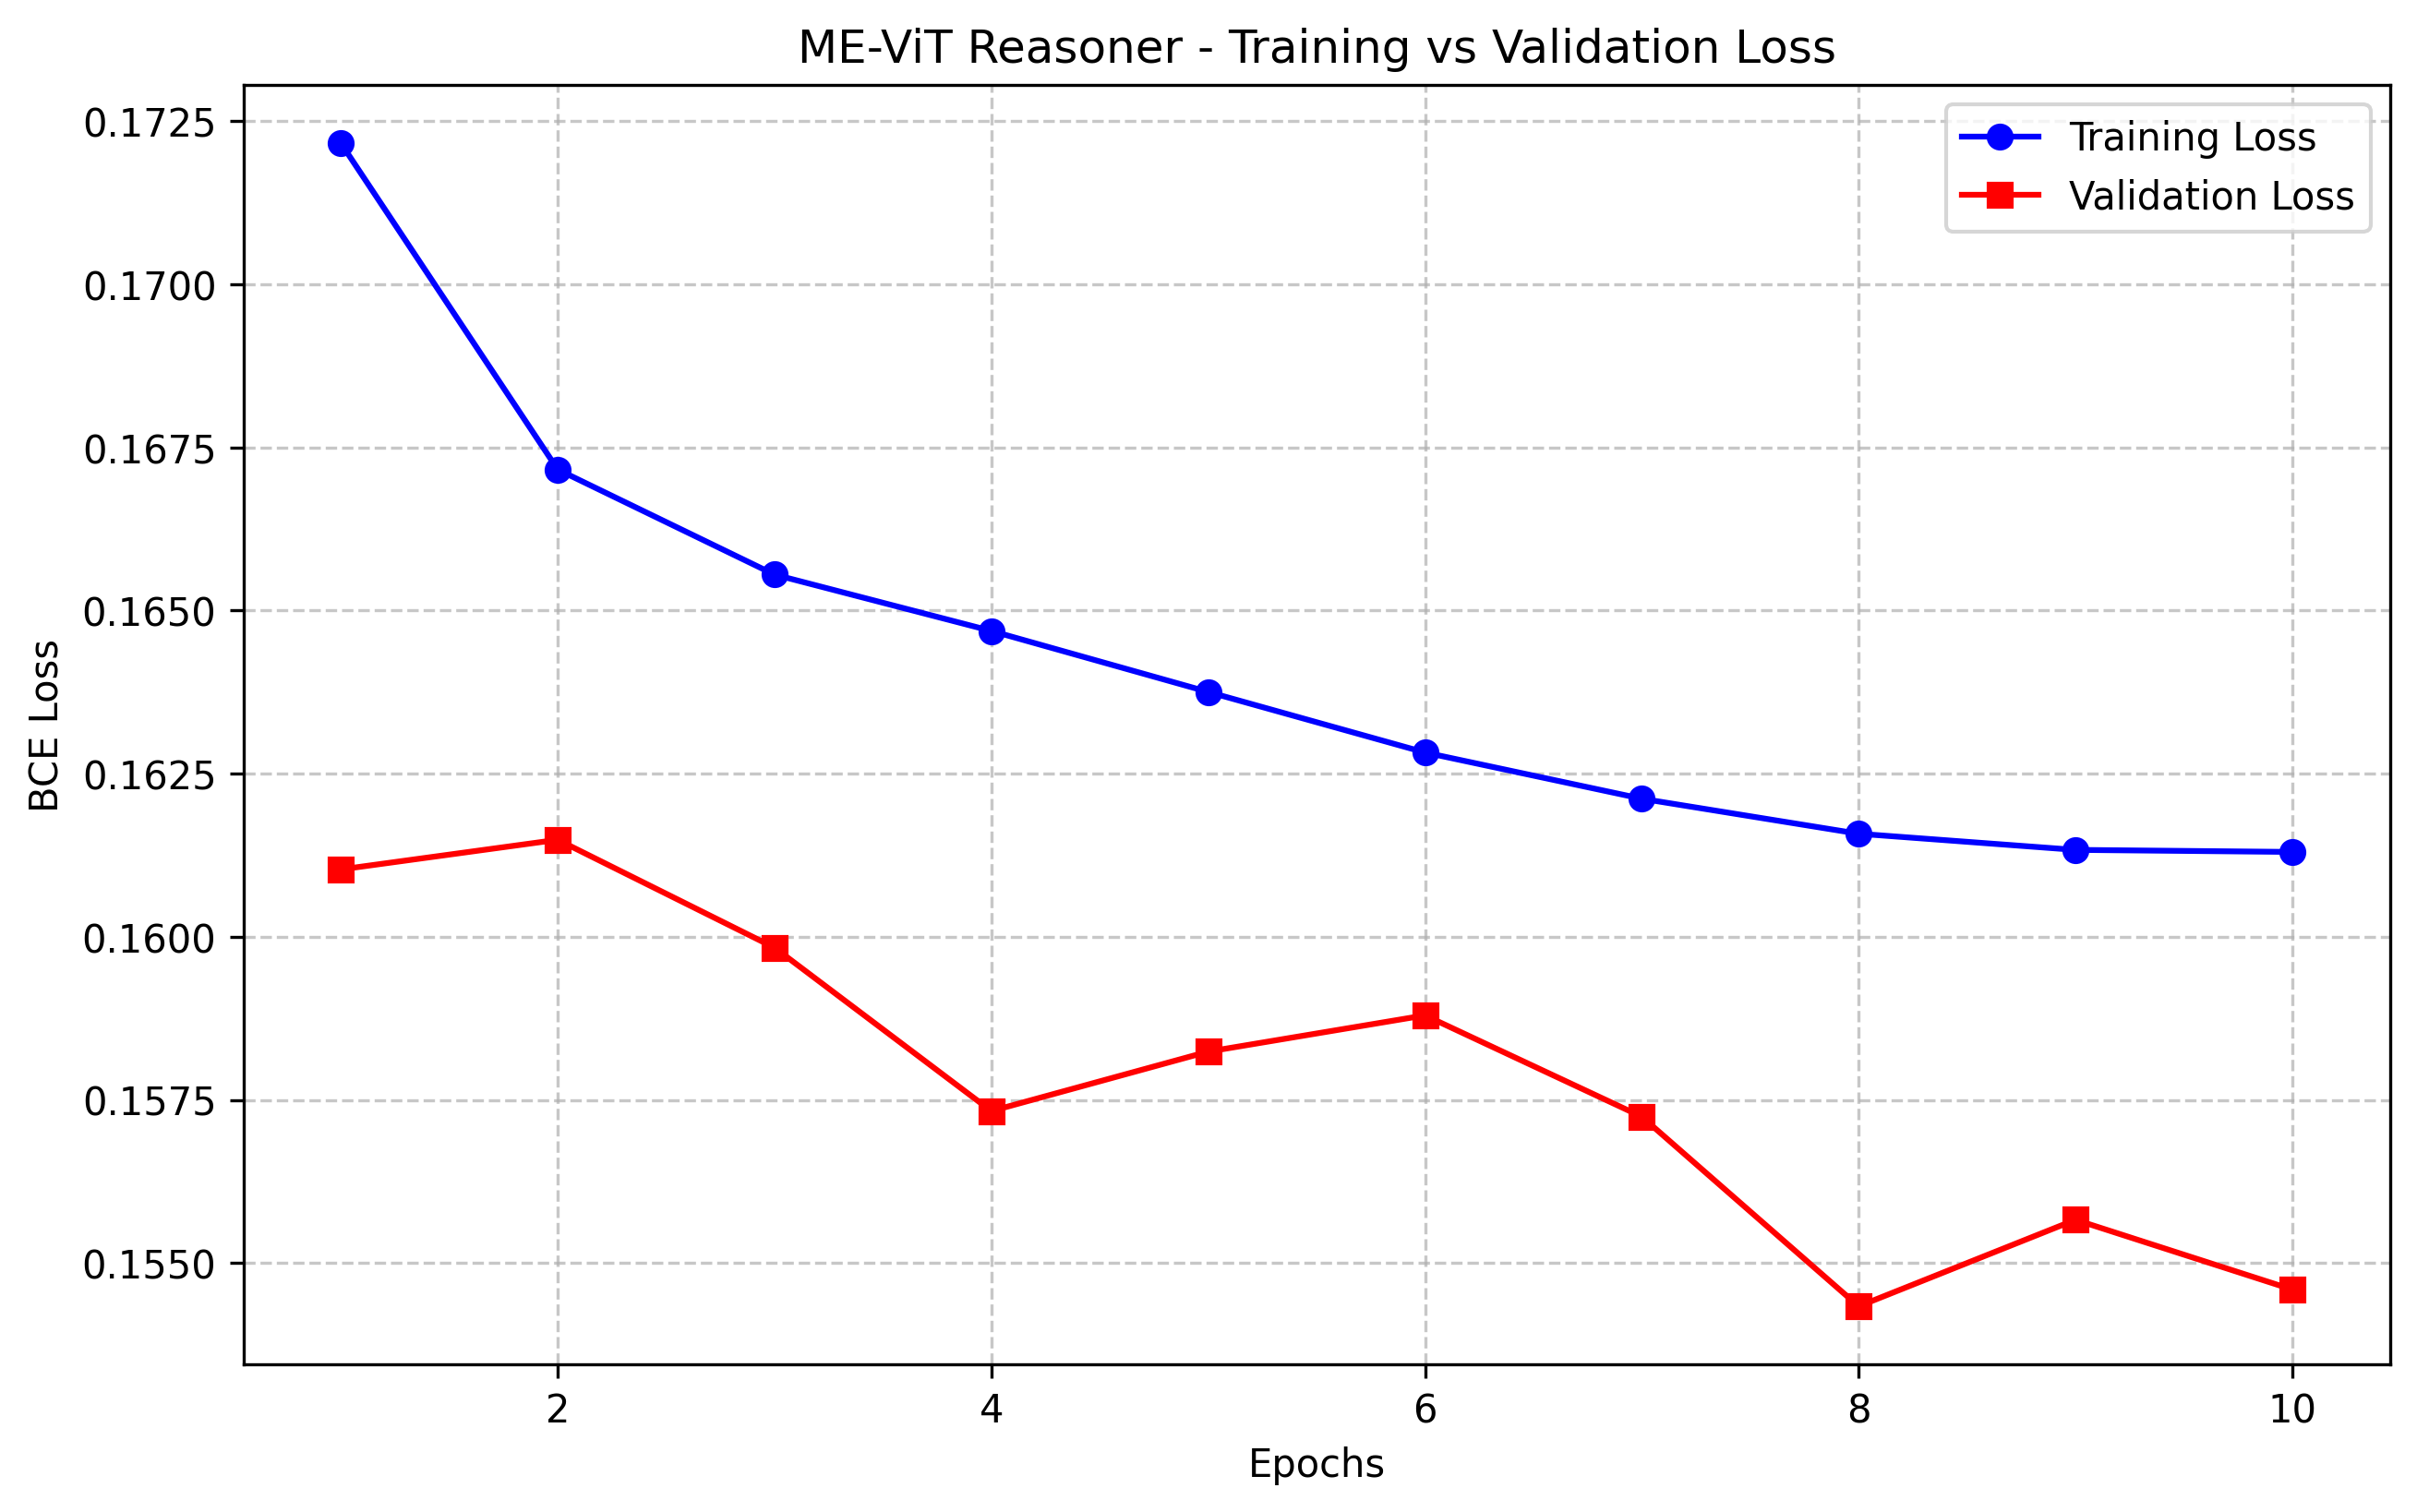

In [6]:
from utils.plot_metrics import plot_training_losses
from IPython.display import display, Image

plot_path = plot_training_losses(train_history, val_history, save_dir=WEIGHTS_DIR)
print(f"Loss curve saved to: {plot_path}")
display(Image(filename=plot_path))

## 5. Evaluation: Top-1 Task-Aware Fusion Accuracy
Loads the best saved checkpoint, runs full YOLO + ME-ViT late-fusion over the test set, and reports the percentage of images where the highest-scoring fused box overlaps a human-preferred ground-truth box at IoU > 0.5.

In [7]:
from utils.evaluate import evaluate_best_model

accuracy = evaluate_best_model(
    data_root    = DATA_ROOT,
    weights_path = os.path.join(WEIGHTS_DIR, 'mevit_best.pt'),
    device       = device
)

Loading Models...
Loading Validation Dataset...
Loaded 12600 PREPROCESSED samples for test split.


Evaluating Top-1 Task Accuracy: 100%|██████████| 12600/12600 [03:34<00:00, 58.80it/s]


Final Evaluation Results!
Total Images Validated: 6173
Correct Top-1 Object Fusions: 1203
Top-1 Task-Aware Accuracy: 19.49%
